# Student Depression Prediction Using Machine Learning

SENG 352 Data Analysis term project. This notebook builds a reproducible binary classification workflow for the Kaggle Student Depression Dataset.

Target variable: `Depression` (`0` = No Depression, `1` = Depression).

All random processes use `random_state = 42`.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

from src.project_pipeline import (
    RANDOM_STATE, TARGET, DATA_PATH, ensure_directories, load_dataset, validate_target,
    data_quality_report, clean_dataset, save_eda_plots, split_features,
    compare_feature_engineering, compare_models, tune_models, evaluate_final_model, save_model,
)

sns.set_theme(style="whitegrid")
ensure_directories()
print(f"Project root: {PROJECT_ROOT}")
print(f"Random state: {RANDOM_STATE}")

Project root: /Users/yagmurtokmakci.m/Desktop/Student_Depression_Prediction/student-depression-prediction
Random state: 42


## 1. Data Loading

The dataset is loaded from `data/raw/`. The first checks verify the expected size, column names, data types, first rows, summary statistics, and the binary target column.

In [2]:
df = load_dataset(DATA_PATH)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes)
print("\nFirst rows:")
display(df.head())
print("\nSummary statistics:")
display(df.describe(include="all").T)

validation = validate_target(df)
validation

Shape: (27901, 18)
Columns:
['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Data types:


id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object


First rows:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,27901.0,NaN,NaN,NaN,70442.149421,40641.175216,2.0,35039.0,70684.0,105818.0,140699.0
Gender,27901,2,Male,15547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,27901.0,NaN,NaN,NaN,25.8223,4.905687,18.0,21.0,25.0,30.0,59.0
City,27901,52,Kalyan,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,27901,14,Student,27870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Pressure,27901.0,NaN,NaN,NaN,3.141214,1.381465,0.0,2.0,3.0,4.0,5.0
Work Pressure,27901.0,NaN,NaN,NaN,0.00043,0.043992,0.0,0.0,0.0,0.0,5.0
CGPA,27901.0,NaN,NaN,NaN,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,NaN,NaN,NaN,2.943837,1.361148,0.0,2.0,3.0,4.0,5.0
Job Satisfaction,27901.0,NaN,NaN,NaN,0.000681,0.044394,0.0,0.0,0.0,0.0,4.0


{'shape': (27901, 18),
 'target_exists': True,
 'target_values': [0, 1],
 'is_binary_target': True}

In [3]:
assert 27000 <= df.shape[0] <= 29000, "Unexpected row count; verify the input CSV."
assert df.shape[1] == 18, "Unexpected feature count; verify the input CSV."
assert validation["target_exists"], "Target column Depression is missing."
assert validation["is_binary_target"], "Depression must contain only binary values 0 and 1."

## 2. Data Quality Assessment

This section checks missing values, duplicate rows, rare categories, unusual numeric values, and IQR outlier counts. Outliers are inspected rather than blindly removed because unusual values can still be real responses or survey coding artifacts.

In [4]:
dqa = data_quality_report(df)

missing = pd.DataFrame({
    "missing_count": pd.Series(dqa["missing"]),
    "missing_pct": pd.Series(dqa["missing"]) / len(df) * 100,
}).sort_values("missing_count", ascending=False)
display(missing)
print("Financial Stress missing values:", dqa["financial_stress_missing"])
print("Duplicate rows:", dqa["duplicate_rows"])
print("Rows with CGPA = 0:", dqa["cgpa_zero_rows"])
print("Rows with Age >= 59:", dqa["age_59_or_higher_rows"])

,missing_count,missing_pct
Financial Stress,3,0.010752
id,0,0.000000
Gender,0,0.000000
Family History of Mental Illness,0,0.000000
Work/Study Hours,0,0.000000
Have you ever had suicidal thoughts ?,0,0.000000
Degree,0,0.000000
Dietary Habits,0,0.000000
Sleep Duration,0,0.000000
Job Satisfaction,0,0.000000


Financial Stress missing values: 3
Duplicate rows: 0
Rows with CGPA = 0: 9
Rows with Age >= 59: 1


In [5]:
outliers = pd.DataFrame(dqa["numeric_outlier_counts_iqr"].items(), columns=["feature", "iqr_outlier_count"])
display(outliers.sort_values("iqr_outlier_count", ascending=False))

print("Rare category checks:")
for col, counts in dqa["rare_categories"].items():
    print(f"\n{col}")
    display(pd.Series(counts, name="count"))

print("Near-zero-variance checks:")
display(pd.DataFrame(dqa["near_zero_variance"]).T)

,feature,iqr_outlier_count
1,Age,12
4,CGPA,9
6,Job Satisfaction,8
3,Work Pressure,3
0,id,0
2,Academic Pressure,0
5,Study Satisfaction,0
7,Work/Study Hours,0
8,Financial Stress,0
9,Depression,0


Rare category checks:

Sleep Duration


Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64


Dietary Habits


Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64

Near-zero-variance checks:


,top_value,top_share,n_unique
Work Pressure,0.0,0.999892,3.0
Job Satisfaction,0.0,0.999713,5.0


### Data Quality Decisions

Rows with missing `Financial Stress` are dropped only if the count is very small. Rare `Others` categories in `Sleep Duration` and `Dietary Habits` are kept because they represent valid survey responses and one-hot encoding can handle them. `CGPA = 0` and high ages are inspected but not automatically removed. `Work Pressure` and `Job Satisfaction` are dropped during modeling after the near-zero-variance evidence confirms they are non-informative in this student-only dataset.

In [6]:
clean_df = clean_dataset(df)
print("Clean shape:", clean_df.shape)
clean_df.to_csv(PROJECT_ROOT / "data/processed/student_depression_clean.csv", index=False)
display(clean_df.head())

Clean shape: (27898, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 3. Exploratory Data Analysis

The plots below are saved into `figures/`. The analysis focuses especially on academic pressure, financial stress, sleep duration, work/study hours, CGPA, suicidal thoughts, and family history of mental illness.

In [7]:
figure_paths = save_eda_plots(clean_df)
print(f"Saved {len(figure_paths)} figures")
for path in figure_paths:
    print(path)

Saved 22 figures
figures/target_distribution.png
figures/numeric_histograms.png
figures/numeric_boxplots.png
figures/numeric_boxplots_by_depression.png
figures/correlation_heatmap.png
figures/categorical_gender.png
figures/categorical_by_depression_gender.png
figures/categorical_city.png
figures/categorical_by_depression_city.png
figures/categorical_profession.png
figures/categorical_by_depression_profession.png
figures/categorical_sleep_duration.png
figures/categorical_by_depression_sleep_duration.png
figures/categorical_dietary_habits.png
figures/categorical_by_depression_dietary_habits.png
figures/categorical_degree.png
figures/categorical_by_depression_degree.png
figures/categorical_have_you_ever_had_suicidal_thoughts_.png
figures/categorical_by_depression_have_you_ever_had_suicidal_thoughts_.png
figures/categorical_family_history_of_mental_illness.png
figures/categorical_by_depression_family_history_of_mental_illness.png
figures/selected_pairplot.png


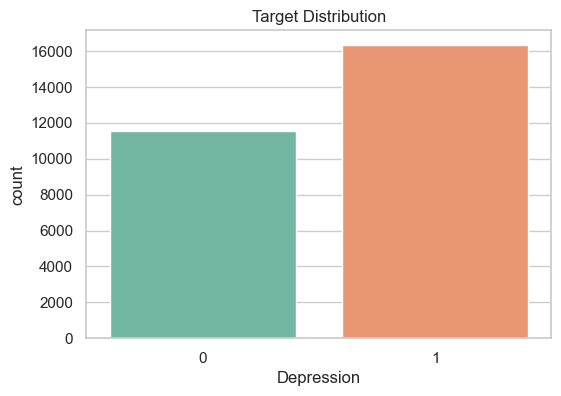

,Academic Pressure,Financial Stress,Work/Study Hours,CGPA,Sleep Duration,Have you ever had suicidal thoughts ?,Family History of Mental Illness,Depression
0,5.0,1.0,3.0,8.97,5-6 hours,Yes,No,1
1,2.0,2.0,3.0,5.90,5-6 hours,No,Yes,0
2,3.0,1.0,9.0,7.03,Less than 5 hours,No,Yes,0
3,3.0,5.0,4.0,5.59,7-8 hours,Yes,Yes,1
4,4.0,1.0,1.0,8.13,5-6 hours,Yes,No,0


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=clean_df, x=TARGET, hue=TARGET, palette="Set2", legend=False)
plt.title("Target Distribution")
plt.show()

focus_cols = [
    "Academic Pressure", "Financial Stress", "Work/Study Hours", "CGPA",
    "Sleep Duration", "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness", TARGET
]
display(clean_df[[c for c in focus_cols if c in clean_df.columns]].head())

### EDA Interpretation

The target distribution shows whether class imbalance exists and motivates the use of stratified splitting and class-weighted models. Academic and financial stress variables are expected to be strong risk indicators. Sleep and lifestyle variables can interact with academic pressure, so they are considered in feature engineering rather than only as isolated predictors.

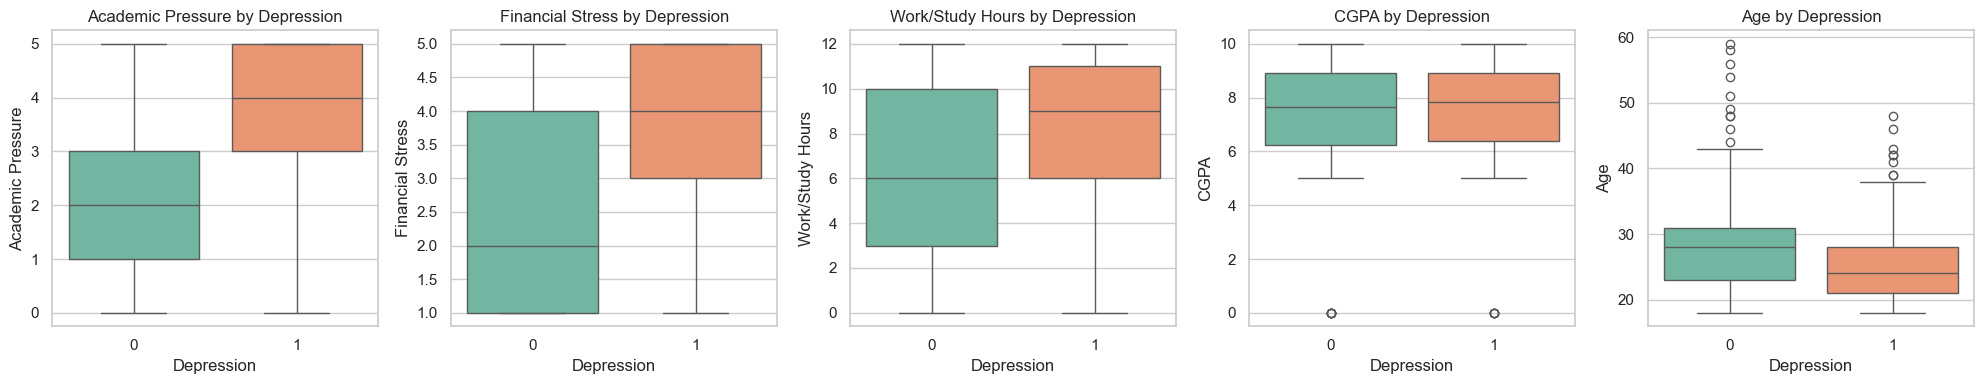

In [9]:
numeric_focus = [c for c in ["Academic Pressure", "Financial Stress", "Work/Study Hours", "CGPA", "Age"] if c in clean_df.columns]
fig, axes = plt.subplots(1, len(numeric_focus), figsize=(4 * len(numeric_focus), 4))
if len(numeric_focus) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_focus):
    sns.boxplot(data=clean_df, x=TARGET, y=col, hue=TARGET, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{col} by Depression")
plt.tight_layout()
plt.show()

## 4. Preprocessing and Train-Test Split

The pipeline uses an 80/20 stratified train-test split. Numeric variables are scaled using `StandardScaler`, and nominal categorical variables are one-hot encoded. Scaling and encoding are fitted only on the training folds through the sklearn pipeline.

In [10]:
X_train, X_test, y_train, y_test = split_features(clean_df)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))
print("Test target distribution:")
display(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (22318, 17) Test shape: (5580, 17)
Train target distribution:


Depression
1    0.585536
0    0.414464
Name: proportion, dtype: float64

Test target distribution:


Depression
1    0.585484
0    0.414516
Name: proportion, dtype: float64

### Sleep Duration Encoding Decision

`Sleep Duration` is treated as nominal for the main preprocessing because `Others` has no reliable position in an ordinal scale. For the engineered interaction only, the ordered sleep ranges are converted into approximate hour estimates; `Others` is filled using the training median inside the transformer.

## 5. Feature Engineering

The workflow compares performance with and without engineered features. The required engineered feature is `Academic_Pressure_x_Sleep`, based on academic pressure multiplied by estimated sleep hours. Additional tested features include stress load, academic lifestyle load, sleep estimate, and CGPA category.

In [11]:
feature_engineering_results = compare_feature_engineering(X_train, y_train)
feature_engineering_results.to_csv(PROJECT_ROOT / "feature_engineering_comparison.csv", index=False)
display(feature_engineering_results)

,engineered_features,cv_f1_macro_mean,cv_roc_auc_mean
0,False,0.839553,0.921548
1,True,0.839424,0.921478


## 6. Modeling

Models are compared using the same train-test split and stratified 5-fold cross-validation. Metrics include accuracy, precision, recall, F1-score, macro F1-score, and ROC-AUC. Class imbalance is handled with `class_weight="balanced"` where applicable. XGBoost is included automatically when installed.

In [12]:
model_comparison = compare_models(X_train, y_train)
display(model_comparison)

,model,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_f1_macro_mean,cv_f1_macro_std,cv_roc_auc_mean,cv_roc_auc_std
4,MLP Classifier,0.848329,0.006269,0.857582,0.007048,0.888660,0.011903,0.872774,0.005704,0.842486,0.006366,0.920871,0.003266
0,Logistic Regression,0.847791,0.006487,0.857614,0.006481,0.887435,0.007894,0.872246,0.005519,0.841992,0.006724,0.921444,0.003006
1,Logistic Regression Balanced,0.843176,0.005525,0.877996,0.006846,0.850398,0.006541,0.863951,0.004745,0.839424,0.005703,0.921478,0.003049
3,Random Forest Balanced,0.843042,0.004533,0.854199,0.004900,0.882614,0.003166,0.868169,0.003641,0.837122,0.004806,0.916270,0.003144
2,Decision Tree Balanced,0.777310,0.004682,0.811629,0.004582,0.807009,0.007054,0.809292,0.004312,0.770854,0.004743,0.771180,0.004725


## 7. Hyperparameter Tuning

The best two promising tunable models are selected from the cross-validation table and tuned with `GridSearchCV` using stratified 5-fold cross-validation. The primary scoring metric is macro F1-score.

In [13]:
top_model_names = model_comparison["model"].tolist()
tuning_results, best_model = tune_models(X_train, y_train, top_model_names)
display(tuning_results)

,model,best_score_f1_macro,best_params
0,Logistic Regression Balanced,0.840969,"{""model__C"": 0.01, ""model__penalty"": ""l2"", ""mo..."
1,Random Forest Balanced,0.839185,"{""model__class_weight"": ""balanced"", ""model__ma..."


## 8. Final Evaluation

The selected tuned model is evaluated once on the held-out test set. This section saves the classification report, confusion matrix, ROC curve, precision-recall curve, feature importance or permutation importance, and final metric CSV files.

In [14]:
final_metrics, evaluation_details = evaluate_final_model(best_model, X_test, y_test)
display(final_metrics)
print("Confusion matrix:")
print(np.array(evaluation_details["confusion_matrix"]))

model_path = save_model(best_model)
print("Saved final model to:", model_path)

,accuracy,precision,recall,f1,macro_f1,roc_auc
0,0.842294,0.87925,0.846954,0.8628,0.83869,0.918866


Confusion matrix:
[[1933  380]
 [ 500 2767]]
Saved final model to: models/final_model.pkl


### Model Selection Discussion

The final model is selected based primarily on cross-validated macro F1-score, with ROC-AUC used as a secondary measure. In depression prediction, recall is especially important because a false negative means a student may be at risk but the model predicts no depression. Increasing recall can produce more false positives, but in an early-warning system that trade-off may be acceptable if follow-up support is non-punitive and reviewed by qualified humans.

## 9. Error Analysis

False positives and false negatives are saved to `reports/misclassified_samples.csv`, and group-level error summaries are saved in `reports/`. False negatives deserve special attention because they correspond to potentially at-risk students being missed.

In [15]:
print("False positives:", evaluation_details["errors"]["false_positives"])
print("False negatives:", evaluation_details["errors"]["false_negatives"])

misclassified = pd.read_csv(PROJECT_ROOT / "reports/misclassified_samples.csv")
display(misclassified.head())

for name, table in evaluation_details["errors"]["group_error_tables"].items():
    print(f"\nError rates by {name}")
    display(pd.DataFrame(table))

False positives: 380
False negatives: 500


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,...,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,actual,predicted,predicted_probability_depression,error_type
0,35289,Male,25.0,Srinagar,Student,2.0,0.0,8.58,3.0,0.0,...,Unhealthy,MCA,Yes,11.0,5.0,Yes,0,1,0.911638,False Positive
1,22234,Male,33.0,Jaipur,Student,3.0,0.0,9.93,5.0,0.0,...,Moderate,M.Tech,Yes,1.0,1.0,No,1,0,0.103930,False Negative
2,131853,Male,32.0,Lucknow,Student,4.0,0.0,7.25,3.0,0.0,...,Moderate,MCA,Yes,9.0,5.0,No,0,1,0.915125,False Positive
3,50394,Female,29.0,Ghaziabad,Student,1.0,0.0,9.11,5.0,0.0,...,Moderate,B.Pharm,Yes,2.0,4.0,Yes,1,0,0.179343,False Negative
4,15147,Female,26.0,Vasai-Virar,Student,5.0,0.0,8.52,4.0,0.0,...,Moderate,LLB,No,0.0,4.0,Yes,1,0,0.407058,False Negative



Error rates by Gender


,Correct,False Negative,False Positive
Female,0.837,0.094,0.069
Male,0.846,0.086,0.068



Error rates by Sleep Duration


...

,Correct,False Negative,False Positive
Healthy,0.848,0.099,0.053
Moderate,0.835,0.087,0.078
Others,0.667,0.000,0.333
Unhealthy,0.846,0.084,0.070



Error rates by Have you ever had suicidal thoughts ?


,Correct,False Negative,False Positive
No,0.836,0.131,0.033
Yes,0.846,0.065,0.089



Error rates by Family History of Mental Illness


,Correct,False Negative,False Positive
No,0.837,0.096,0.067
Yes,0.848,0.083,0.069


### Ethical Limitation

This model must not be used as a clinical diagnostic tool. It can only be considered as a decision-support or early-warning prototype. Any real-world use would require expert review, privacy protection, bias monitoring, careful consent and governance, and institutional approval.

## 10. Final Checklist

The notebook loads the dataset, validates the target, handles missing values, saves EDA plots, builds leakage-safe preprocessing pipelines, compares at least four models, performs cross-validation, tunes the best models, evaluates a final model on the held-out test set, saves the final model, saves metric CSV files, discusses false negatives, and includes ethical limitations.